# 02_分类算法-XGBoost

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文件位于“分类算法”目录，但案例实际是房价回归；本篇保留原目录和回归案例，评估使用回归指标。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


说起来，XGBoost 真的是一个非常厉害的用来处理和分析数据的工具，能从数据中学习规律，然后做出非常准确的预测。

XGBoost 速度快、效果好，而且很灵活，受到太多人的喜欢。

下面，咱们从一些概念、公式和案例和大家一起学习一下\~

XGBoost，全称为 eXtreme Gradient Boosting，XGBoost 是一种提升（Boosting）算法。

它通过将多个简单的模型（通常是决策树）组合在一起，逐步改进模型的预测能力。简单来说，XGBoost就是通过让一群“弱小的”模型一起工作，最终变得“很强大”。而且 XGBoost 用于回归、分类等任务。

下面，给出大家4个 XGBoost 的优点，大家可以很好的有一个大致印象\~

- **高效：** 算法速度快，计算资源利用效率高。
- **准确：** 可以处理复杂的数据，生成高质量的预测。
- **灵活：** 可以处理各种类型的数据，包括缺失值和类别变量。
- **可扩展：** 适用于大规模数据集，可以在分布式环境中运行。

假设我们要预测一个学生的考试成绩。

我们可以使用XGBoost来建立模型：

- 第一步，我们用一些简单的规则（比如，学生是否参加了补习班，是否每天学习超过2小时等）建立一个初步的预测模型。这是我们的一棵“决策树”。
- 第二步，我们观察这棵树预测的误差（比如，某些学生的成绩预测过高或过低），然后再建立一棵新的决策树，专门来纠正这些误差。
- 重复这个过程，建立多棵决策树，每棵树都修正前面树的错误。
- 最终，我们把所有树的预测结果综合起来，就得到了一个非常准确的预测模型。

## 理论基础

基础原理这部分，我会从 XGBoost 的数学原理、公式推理和算法流程三大部分和大家进行阐述\~

### 目标函数

XGBoost 的目标函数由两个部分组成：**损失函数和正则化项**。

目标函数的表达式为：


$$
\mathcal{L}(\theta) = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)
$$


其中：

- $y_i$是真实值
- $\hat{y}_i$是预测值
- $l$是损失函数，通常为均方误差 (MSE) 或对数损失
- $f_k$是第 $k$棵树
- $\Omega$是正则化项，用于控制模型的复杂度

### 梯度提升

XGBoost 通过逐步添加树来最小化损失函数，每一步都是在前一步的基础上改进预测。

假设我们已经有了 $t-1$棵树，第 $t$棵树的目标是最小化下述的增量损失函数：


$$
\mathcal{L}^{(t)} = \sum_{i=1}^{n} l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)
$$


其中：

$\hat{y}_i^{(t-1)}$是前 $t-1$棵树的预测值

$f_t(x_i)$是第 $t$棵树的预测值

### 泰勒展开

为了简化目标函数，我们对损失函数进行二阶泰勒展开：


$$
\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} \left[ l(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2 \right] + \Omega(f_t)
$$


其中：

- $g_i = \frac{\partial l(y_i, \hat{y}_i^{(t-1)})}{\partial \hat{y}_i^{(t-1)}}$是一阶导数（梯度）
- $h_i = \frac{\partial^2 l(y_i, \hat{y}_i^{(t-1)})}{\partial \hat{y}_i^{(t-1)^2}}$是二阶导数（Hessian）

将常数项去掉后，简化为：


$$
\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2 \right] + \Omega(f_t)
$$


### 树模型和正则化

XGBoost 中每棵树的模型可以表示为：


$$
f_t(x) = w_{q(x)}
$$


其中：

- $q$是叶子节点的索引函数，将输入 $x$映射到叶子节点 $q(x)$
- $w$是叶子节点的权重

正则化项定义为：


$$
\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2
$$


其中：

$T$是叶子节点的数量

$\gamma$和 $\lambda$是正则化参数，控制树的复杂度

### 最优化目标

将树模型和正则化项代入简化的目标函数：


$$
\mathcal{L}^{(t)} = \sum_{i=1}^{n} \left[ g_i w_{q(x_i)} + \frac{1}{2} h_i w_{q(x_i)}^2 \right] + \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2
$$


对同一个叶子节点的样本求和：


$$
\mathcal{L}^{(t)} = \sum_{j=1}^{T} \left[ G_j w_j + \frac{1}{2} (H_j + \lambda) w_j^2 \right] + \gamma T
$$


其中：

$G_j = \sum_{i \in I_j} g_i$是第 $j$个叶子节点的梯度之和

$H_j = \sum_{i \in I_j} h_i$是第 $j$个叶子节点的 Hessian 之和

通过对 $w_j$求导并令其为零，得到最优的叶子节点权重：

$w_j^* = -\frac{G_j}{H_j + \lambda}$  
将最优权重代入目标函数，得到最小化后的目标值：


$$
\mathcal{L}^{(t)} = -\frac{1}{2} \sum_{j=1}^{T} \frac{G_j^2}{H_j + \lambda} + \gamma T
$$


### 树的分裂

为了找到最优的分裂点，XGBoost 计算每个候选分裂点的增益：


$$
\text{Gain} = \frac{1}{2} \left( \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right) - \gamma
$$


其中：

$G_L$和 $H_L$分别是左子节点的梯度和 Hessian 之和

$G_R$和 $H_R$分别是右子节点的梯度和 Hessian 之和

选择增益最大的分裂点进行分裂。

### 算法流程

XGBoost 的整体算法流程：

**1. 初始化：** 初始化预测值 $\hat{y}_i^{(0)}$为一个常数值（通常为目标值的平均值）。

**2. 迭代：** 对于每一棵树 $t$，进行以下步骤：

**a. 计算梯度和 Hessian：** 计算每个样本的梯度 $g_i$和 Hessian $h_i$。

**b. 构建树：** 逐层分裂节点，计算每个候选分裂点的增益，选择增益最大的分裂点，直至达到预设的叶子节点数或增益小于阈值。

**c. 计算叶子节点权重：** 根据梯度和 Hessian 计算每个叶子节点的权重 $w_j^*$。

**3. 更新预测值：** 更新每个样本的预测值 $\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_t(x_i)$。

通过以上步骤，不断迭代构建新的树，每棵树都在前一棵树的基础上改进，最终得到一个强大的模型。

好了，在所有的理论之后，后面给大家分享一个比较合适的案例，大家可以根据代码以及注释的内容进行学习\~

## 完整案例

来到了案例部分\~

整个代码实现过程，通过数据预处理、特征工程、模型训练和优化以及可视化展示结果。我们选择Kaggle上的房价预测数据集（House Prices - Advanced Regression Techniques）来进行演示。

数据集获取，公众号「深夜努力写Python」后台回复『数据集』即可\~

**导入库和数据集**

In [2]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# 导入数据集
train_data = pd.read_csv(DATA_DIR / 'housing.csv')
train_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**数据预处理**

In [3]:
# 检查缺失值
train_data.isnull().sum()

# 填充缺失值
train_data['total_bedrooms'].fillna(train_data['total_bedrooms'].median(), inplace=True)

# 创建特征
train_data['rooms_per_household'] = train_data['total_rooms'] / train_data['households']
train_data['bedrooms_per_room'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['population_per_household'] = train_data['population'] / train_data['households']

# 将分类特征转换为数值
train_data = pd.get_dummies(train_data, columns=['ocean_proximity'], drop_first=True)

# 定义特征和标签
X = train_data.drop('median_house_value', axis=1)
y = train_data['median_house_value']

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_9642/841374400.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['total_bedrooms'].fillna(train_data['total_bedrooms'].median(), inplace=True)


**数据集划分**

In [4]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**模型训练**

In [5]:
# 创建XGBoost回归模型
xgb_reg = xgb.XGBRegressor(n_jobs=1)

# 训练模型
xgb_reg.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


**模型评估**

RMSE: 47501.7157


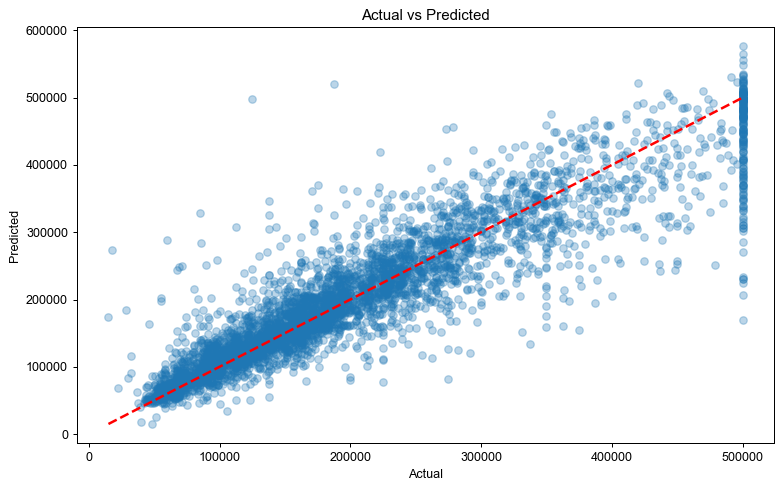

In [6]:
# 预测
y_pred = xgb_reg.predict(X_test)

# 均方根误差
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")

# 可视化实际值与预测值的关系
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_031.png)

**模型优化（超参数调优）**

Fitting 3 folds for each of 32 candidates, totalling 96 fits


Best parameters: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Optimized RMSE: 46066.2746


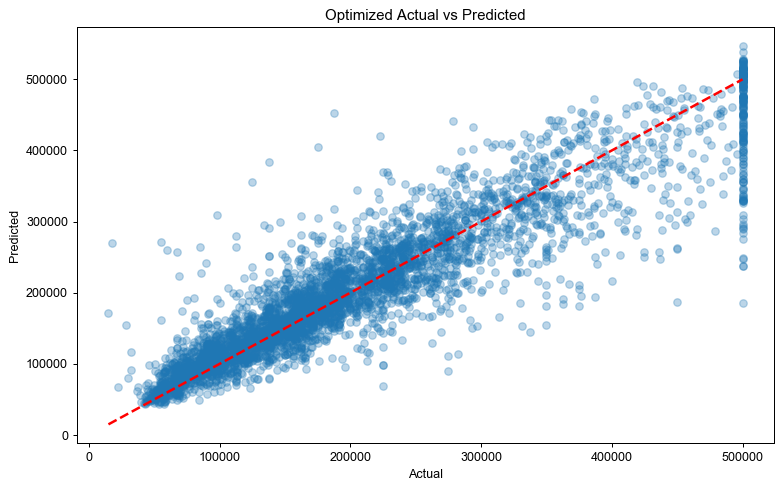

In [7]:
# 参数网格
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# 网格搜索
grid_search = GridSearchCV(estimator=xgb_reg, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1, error_score='raise')
grid_search.fit(X_train, y_train)

# 最优参数
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

# 使用最优参数训练模型
xgb_reg_optimized = xgb.XGBRegressor(**best_params, n_jobs=1)
xgb_reg_optimized.fit(X_train, y_train)

# 预测
y_pred_optimized = xgb_reg_optimized.predict(X_test)

# 均方根误差
rmse_optimized = np.sqrt(mean_squared_error(y_test, y_pred_optimized))
print(f"Optimized RMSE: {rmse_optimized:.4f}")

# 可视化实际值与预测值的关系（优化后）
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_optimized, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Optimized Actual vs Predicted')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_032.png)

**特征重要性**

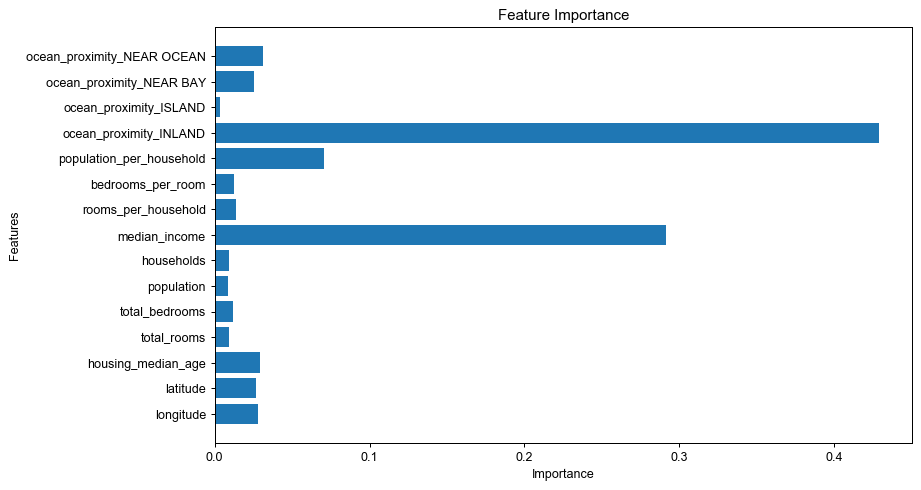

In [8]:
# 特征重要性
importance = xgb_reg_optimized.feature_importances_
features = X.columns

# 可视化
plt.figure(figsize=(10, 6))
plt.barh(features, importance)
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_033.png)

整个代码的过程中，展示了如何使用XGBoost算法对房价数据集进行预测。通过数据预处理、特征工程、模型训练、评估、优化和特征重要性可视化，完整地展示了机器学习项目的流程。通过超参数调优，可以显著提高模型的预测性能。在实际项目中，大家可以根据需要调整数据预处理和模型优化的步骤和参数，获得更好的效果。

## 模型分析

**使用XGBoost模型的优缺点**

**优点**：

- **高效性**：XGBoost在计算上非常高效，支持并行和分布式计算，能够处理大型数据集。
- **性能优越**：它通常在结构化数据集上表现出色，具有较高的预测准确率。
- **自动化特征选择**：通过树模型自动选择重要特征，减少了手动特征选择的工作量。
- **防止过拟合**：通过内置的正则化参数（如(\gamma)和(\lambda)）控制模型复杂度，防止过拟合。
- **灵活性**：支持多种目标函数和自定义目标函数，适用于分类和回归问题。
- **处理缺失值**：自动处理缺失值，推测出合适的分支方向。

**缺点**：

- **参数调优复杂**：需要调整多个超参数以获得最佳性能，调优过程可能较为复杂和耗时。
- **对内存要求较高**：在处理非常大的数据集时，内存占用较高，可能需要大量内存。
- **对数据预处理敏感**：尽管XGBoost自动处理缺失值，但数据标准化、归一化等预处理仍然重要，影响模型性能。

### 与相似算法的对比

| **对比项** | **XGBoost vs. Random Forest** | **XGBoost vs. GBDT** |
|-|-|-|
| **算法类别** | 都是基于决策树的集成学习方法 | 都属于提升法（Boosting） |
| **基学习器** | 决策树 | 决策树 |
| **主要区别** | XGBoost 使用提升法（Boosting），每棵树依赖于前一棵树；随机森林使用袋装法（Bagging），每棵树独立训练 | XGBoost 是 GBDT 的高效实现，加入了正则化、并行计算等优化 |
| **处理问题类型** | 分类和回归 | 分类和回归 |
| **特征选择能力** | 都具有较强的特征选择能力 | 都具有较强的特征选择能力 |
| **性能** | XGBoost 在大规模、高维数据上通常比随机森林表现更好 | XGBoost 在计算效率和优化上优于传统 GBDT |
| **计算复杂度** | XGBoost 计算复杂度较高，但可以通过并行计算提高效率；随机森林计算复杂度较低 | XGBoost 计算效率更高，优化了内存使用和计算资源 |
| **超参数调优** | 随机森林超参数较少，较容易调优 | XGBoost 拥有更多可调参数，使得调优更灵活 |
| **并行计算** | 随机森林天生支持并行，每棵树可独立训练 | XGBoost 通过优化支持并行计算，但仍是串行提升的方式 |
| **正则化处理** | 随机森林没有显式的正则化 | XGBoost 引入 L1、L2 正则化，降低过拟合风险 |
| **适用场景** | 适用于解释性要求高、数据关系复杂但不强依赖顺序的任务 | 适用于对计算性能要求高、需要精细调优的任务，如金融、推荐系统等 |

- **何时选择 XGBoost**：当数据量大、特征多、需要高精度预测时，XGBoost 是更好的选择。
- **何时选择 Random Forest**：当计算资源有限，且需要解释性强的模型时，随机森林更适合。
- **何时选择 GBDT**：XGBoost 是 GBDT 的优化版本，如果使用传统 GBDT，建议切换到 XGBoost 以获得更高的计算效率和优化能力。

## 最后

以上阐述了整个的XGBoost。XGBoost作为一种强大的集成学习算法，在许多应用场景中表现出色，尤其适用于大规模结构化数据集。

通过高效的实现、强大的特征选择能力和防止过拟合的机制，成为机器学习比赛和实际应用中的热门选择。然而，在数据规模较小、计算资源受限或非结构化数据的情况下，其他算法可能更为适用。

因此，根据具体的应用场景和需求，选择合适的算法至关重要。